# **Data Understanding**

#### 1. Initial data exploration
#### 2. Data quality assessment
        - Duplicates
        - Missing Values
        - Logical Inconsistencies
#### 3. Numerical features analysis
#### 4. Categorical features analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from scipy import stats
from matplotlib.ticker import ScalarFormatter


In [2]:
file_name= "../dm1_25_26_dataset/DM1_game_dataset.csv"
df = pd.read_csv(file_name)

In [3]:
df

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,21926,0,0,0,0,0,0,0,0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21920,3233,Ballast,variation game quotpick sticksquot wooden cyli...,1998,1.0000,1.2096,2,4,8.0,11.0,...,21926,0,0,0,0,0,0,0,0,Low
21921,13359,Leapfrog,leapfrog fun family game simple young gamer pl...,2004,1.5000,1.7219,1,6,6.0,361.0,...,21926,0,0,0,0,0,0,0,0,Medium
21922,3295,Athos,monk climb athos mountain reach monastery move...,1993,1.6667,1.7946,2,4,11.0,431.0,...,21926,0,0,0,0,0,0,0,0,Low
21923,176524,Hoplomachus: Origins,hoplomachu origin take story begin small battl...,2015,3.0370,3.2921,1,2,13.8,322.0,...,21926,0,1,0,0,0,0,0,0,High


### **1. Initial data exploration**

In [4]:
df.shape    

(21925, 46)

In [5]:
df.head()       

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


In [6]:
df.tail()       

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
21920,3233,Ballast,variation game quotpick sticksquot wooden cyli...,1998,1.0000,1.2096,2,4,8.0,11.0,...,21926,0,0,0,0,0,0,0,0,Low
21921,13359,Leapfrog,leapfrog fun family game simple young gamer pl...,2004,1.5000,1.7219,1,6,6.0,361.0,...,21926,0,0,0,0,0,0,0,0,Medium
21922,3295,Athos,monk climb athos mountain reach monastery move...,1993,1.6667,1.7946,2,4,11.0,431.0,...,21926,0,0,0,0,0,0,0,0,Low
21923,176524,Hoplomachus: Origins,hoplomachu origin take story begin small battl...,2015,3.0370,3.2921,1,2,13.8,322.0,...,21926,0,1,0,0,0,0,0,0,High
21924,4814,Rubout,rulesquotthe goal rubout player cash hand pl...,1989,1.7692,1.9113,2,8,12.0,1199.0,...,21926,0,0,0,0,0,1,0,0,Low


In [7]:
df.info()       #overview of data structure and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  object 
 2   Description          21924 non-null  object 
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  int64  
 8   ComAgeRec            16395 non-null  float64
 9   LanguageEase         16034 non-null  float64
 10  BestPlayers          21925 non-null  int64  
 11  GoodPlayers          21925 non-null  object 
 12  NumOwned             21925 non-null  int64  
 13  NumWant              21925 non-null  int64  
 14  NumWish              21925 non-null  int64  
 15  NumWeightVotes       21925 non-null 

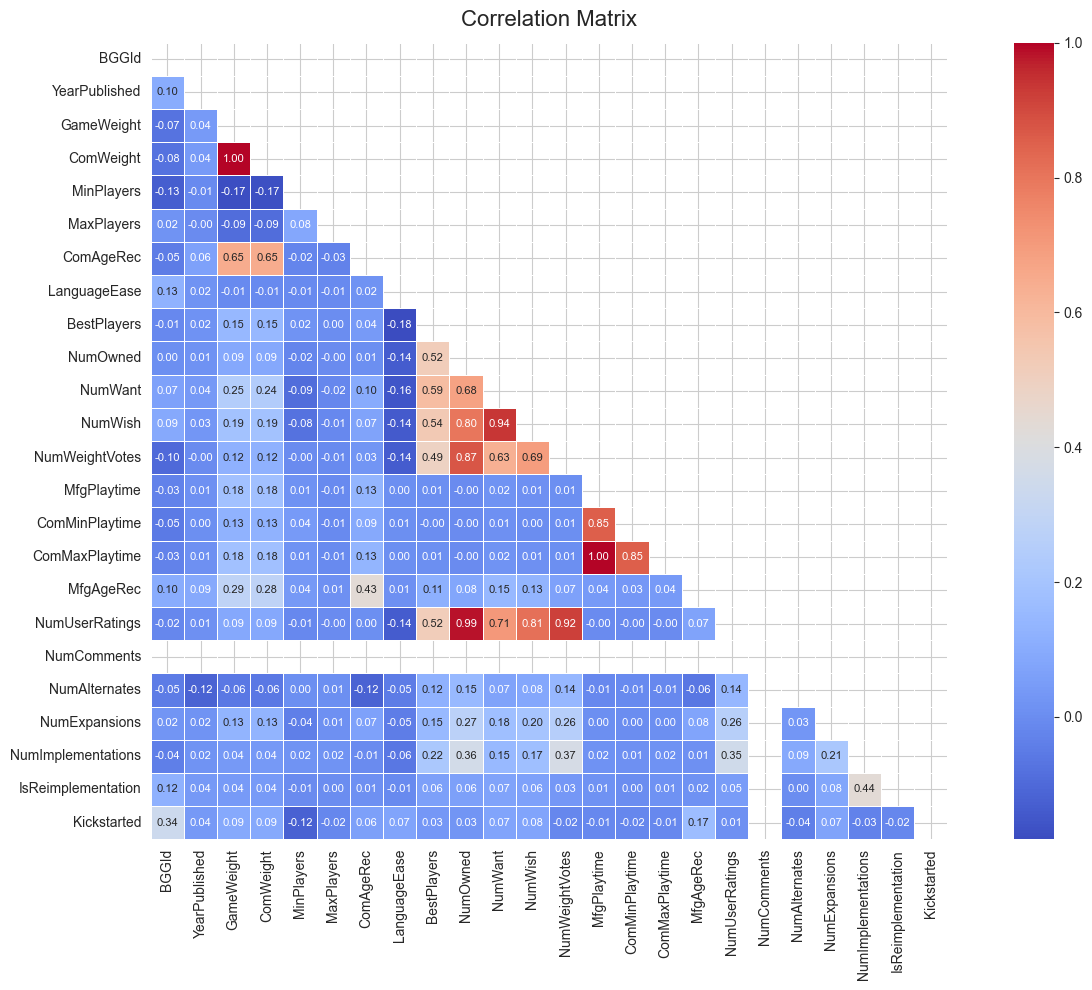

In [8]:
# 1. Seleziona tutte le colonne numeriche
numeric_df = df.select_dtypes(include="number")

# 2. Escludi automaticamente TUTTE le colonne che iniziano con Cat: o Rank:
cols_to_drop = [c for c in numeric_df.columns if c.startswith("Cat:") or c.startswith("Rank:")]
numeric_df = numeric_df.drop(columns=cols_to_drop)

# 3. Matrice di correlazione
corr_matrix = numeric_df.corr()

# 4. Maschera triangolo superiore
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Plot della heatmap
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix", fontsize=16, pad=12)
plt.tight_layout()
plt.show()


### **2. Data quality assessment**

### Duplicates

In [9]:
df['BGGId'].duplicated().sum()      # no games with the same ID

np.int64(0)

In [10]:
df['Name'].duplicated().sum()       # 404 duplicated names (bc some games migh have different versions)

np.int64(404)

In [11]:
n_same_descrip = df['Description'].duplicated().sum()
print(f"Total number of games with the same description (repetitions): {n_same_descrip}\n")

same_descrip_df = df[df['Description'].duplicated(keep=False)].copy()

same_descrip_sorted = same_descrip_df.sort_values(by='Description')

print("Games grouped by identical description:\n")
# Iterate over each group of games sharing the same description
for description, group in same_descrip_sorted.groupby('Description'):
    # Calculate the number of games in this specific group
    game_count = len(group)
    
    print("--- Duplicated Description Group ---")
    print(f"Description: {description}")
    print(f"Number of Games in this group: {game_count}\n")
    print("Game Names:")
    print(group['Name'].to_string(index=False))
    print("\n")

Total number of games with the same description (repetitions): 21

Games grouped by identical description:

--- Duplicated Description Group ---
Description: award win game orcs die way table orcs die boardgame dare preserve stronghold siege orcs trap amp weapon galore team friend obliterate nasty orcs grotesque alliesorcs die boardgame include score figure favorite hero plus horde orcs crossbow orcs kobolds gnoll troll ogre build exciting fortress tilebase system watch swarm baddie plunge defense abolish riftorcs die boardgame   actually consist separate game base heroic order unchained complete standalone game order yoursquoll play hero maximilian war mage gabriella redeem sorceress fend villainous orc onslaught unchained play oppose hero kobold king midnight assassin face assault human soldier lion elf bear dwarfs likehow playedfirst friend choose hero ndash individual game support   player cooperate survive enemy onslaught hero individual sheet unique characteristic special ability

### Missing values

In [12]:
# across all features of the dataset
missing_counts = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Absolute Count': missing_counts,
    'Percentage': missing_percentage
})
missing_info = missing_info.sort_values(by='Absolute Count', ascending=False)

print(missing_info)

                     Absolute Count  Percentage
Family                        15262   69.610034
LanguageEase                   5891   26.868871
ComAgeRec                      5530   25.222349
ImagePath                        17    0.077537
Description                       1    0.004561
YearPublished                     0    0.000000
ComWeight                         0    0.000000
GameWeight                        0    0.000000
MaxPlayers                        0    0.000000
MinPlayers                        0    0.000000
BestPlayers                       0    0.000000
GoodPlayers                       0    0.000000
Name                              0    0.000000
BGGId                             0    0.000000
NumWant                           0    0.000000
NumOwned                          0    0.000000
NumWish                           0    0.000000
NumWeightVotes                    0    0.000000
ComMaxPlaytime                    0    0.000000
MfgAgeRec                         0    0

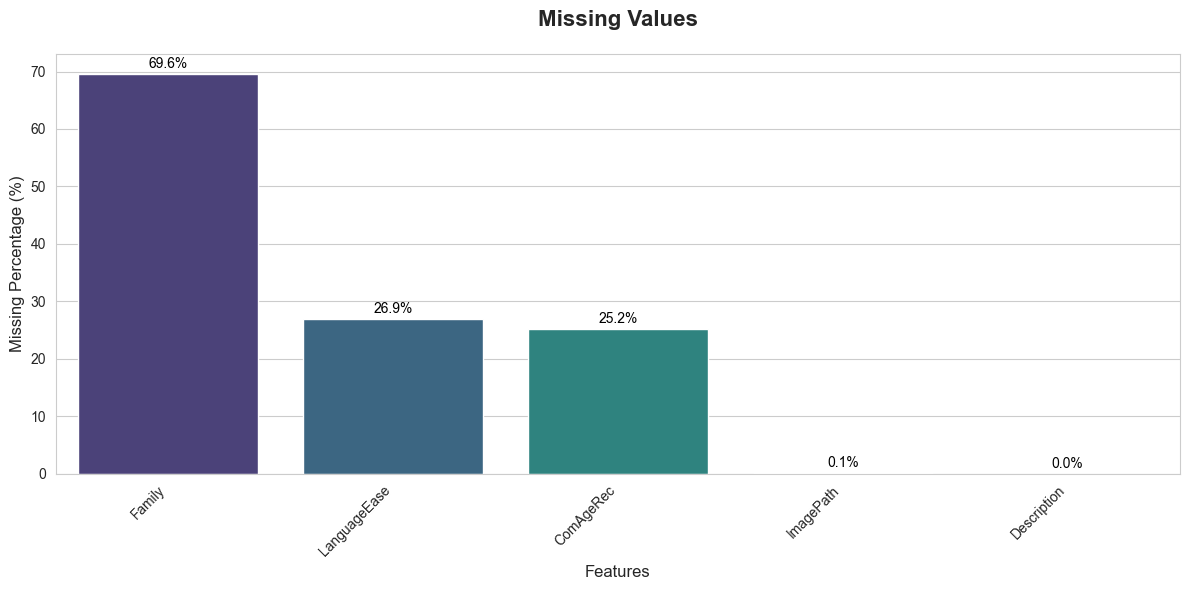

In [13]:
missing_data = df.isnull().mean() * 100

missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")  # Imposta uno sfondo pulito con griglia

# Creazione del barplot
# palette="viridis" crea una sfumatura di colori dal giallo al viola in base all'ordine
barplot = sns.barplot(x=missing_data.index, y=missing_data.values, palette="viridis", hue=missing_data.index, legend=False)

# --- 3. Personalizzazione Estetica ---
plt.title("Missing Values", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Missing Percentage (%)", fontsize=12)
plt.xlabel("Features", fontsize=12)

# Ruota le etichette dell'asse X per evitare sovrapposizioni
plt.xticks(rotation=45, ha='right')

# --- 4. Aggiunta delle etichette sopra le barre ---
# Questo ciclo aggiunge la % esatta sopra ogni barra
for p in barplot.patches:
    height = p.get_height()
    barplot.text(
        p.get_x() + p.get_width() / 2.,  # Posizione X (centro della barra)
        height + 0.5,                    # Posizione Y (sopra la barra)
        f'{height:.1f}%',                # Testo formattato (es. 25.2%)
        ha="center", va="bottom", fontsize=10, color="black"
    )

# Ottimizza gli spazi e mostra
plt.tight_layout()
plt.show()

### Number of games that do not belong to any category

In [14]:
cat_features = [
    'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 
    'Cat:Abstract', 'Cat:Party', 'Cat:Childrens'
]

df['Total_Categories'] = df[cat_features].sum(axis=1)

# if 'Total_Categories' == 0, the game does not belong to any of the listed categories
no_cat_games = df[df['Total_Categories'] == 0]

print(f"Total number of games: {len(df)}")
print(f"Number of games without any listed category: {len(no_cat_games)} ({(len(no_cat_games) / len(df)) * 100:.2f}%)")
print("-" * 35)

if not no_cat_games.empty:
    print("List of games without categories:")
    # Display only the game name and the control column
    print(no_cat_games[['Name', 'Total_Categories'] + cat_features])
else:
    print("All games in the dataset belong to at least one of the listed categories.")

Total number of games: 21925
Number of games without any listed category: 11852 (54.06%)
-----------------------------------
List of games without categories:
                          Name  Total_Categories  Cat:Strategy  Cat:War  \
0      Assassin's Creed: Arena                 0             0        0   
1                 Bag of Chips                 0             0        0   
2       Gùgōng: Deluxe Big Box                 0             0        0   
3                   LetterFlip                 0             0        0   
4          Treasures of Cibola                 0             0        0   
...                        ...               ...           ...      ...   
21918        Zoom in Barcelona                 0             0        0   
21919                   Diam's                 0             0        0   
21920                  Ballast                 0             0        0   
21921                 Leapfrog                 0             0        0   
21922           

### Number of games that belong to more than 1 category at the same time

In [15]:
df['Total_Categories'] = df[cat_features].sum(axis=1)
multi_cat_games = df[df['Total_Categories'] > 1]
print(f"\nNumber of games that belong to more than 1 category at the same time: {len(multi_cat_games)} ({(len(multi_cat_games) / len(df)) * 100:.2f}%)")
print("-" * 35)
if not multi_cat_games.empty:
    print("List of games belonging to more than 1 category:")
    print(multi_cat_games[['Name', 'Total_Categories'] + cat_features])


Number of games that belong to more than 1 category at the same time: 1027 (4.68%)
-----------------------------------
List of games belonging to more than 1 category:
                                               Name  Total_Categories  \
30                                   Dinosaur Chess                 2   
69                                         De Stijl                 2   
91                                        Minuscule                 2   
140                                     Big Manitou                 2   
164                                  Cranium Zigity                 2   
...                                             ...               ...   
21839     San Juan Hill: The Santiago Campaign 1898                 2   
21869                        Yahtzee: Texas Hold'em                 2   
21875                                          Aton                 2   
21879                                     La Strada                 2   
21901  Summoner Wars: Guild 

### Logical inconsistencies

In [16]:
# A game cannot require more minimum players than the maximum allowed
df[df['MinPlayers'] > df['MaxPlayers']]

# The 132 cases occur because MaxPlayers = 0 (which is not a valid value).

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories
206,39342,Bet Your Brain,trivium game question card question card q...,2008,2.3000,2.5258,2,0,9.000000,54.666667,...,0,0,0,0,0,0,0,0,Low,0
209,17568,Magic Robot Quiz Game,market board game magic robot quiz game probab...,1935,1.0000,1.2950,1,0,NaN,NaN,...,0,0,0,0,0,0,0,1,Low,1
604,66809,Flying Lead,fly lead play tabletop action wide range genre...,2010,2.6667,2.9662,2,0,NaN,NaN,...,0,0,1,0,0,0,0,0,High,1
640,38263,Sushi Bar,publisherquotsome chinese character fish shell...,2005,1.0000,1.1104,1,0,5.000000,47.000000,...,0,0,0,0,0,0,0,0,Medium,0
821,22289,Geni!,inside boxgeni question trivium game playersga...,0,1.8000,1.9822,1,0,10.000000,165.000000,...,0,0,0,0,0,0,0,0,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20987,19796,Cranium: The Family Fun Game,manufacturer cranium family fun give family ...,2005,1.4444,1.6321,4,0,9.333333,5.000000,...,0,0,0,1,0,0,0,1,Low,2
21082,1540,BattleTech,battletech aka quotbtquot sciencefiction tacti...,1985,3.4178,3.7111,2,0,11.904762,22.866667,...,1,0,1,0,0,0,0,0,Medium,1
21201,131017,La Bérézina 1812,berezina focus batlle fight remnant napoleon...,2012,2.7500,2.9782,2,0,12.000000,22.500000,...,0,0,1,0,0,0,0,0,High,1
21246,131163,Ghost Hunt,turn light ready big thrillswith magical eye p...,2011,1.5000,1.7810,1,0,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0


In [17]:
# A game cannot have a minimum playtime greater than the maximum playtime
df[df['ComMinPlaytime'] > df['ComMaxPlaytime']]

# Some inconsistencies occur not only because ComMaxPlaytime = 0,
# but also because unrealistic values (e.g., 1 or 30 minutes) were recorded as maximum playtime.

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories
100,197433,Miskatonic School for Boys,description publishermiskatonic school boy new...,2016,1.50,1.7245,3,6,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0
168,285789,Polyhedral Park Planner,big board gaming convention world come city lo...,2019,2.20,2.3922,1,100,10.000000,NaN,...,0,0,0,0,0,0,0,0,Medium,0
176,236556,Artifact Stack,discover old manuscript statue treasure excava...,2017,1.50,1.6919,2,4,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0
793,283795,Würfel-WG,roll dice new flatmember bring dice help launc...,2019,1.50,1.6079,2,4,10.000000,391.666667,...,0,0,0,0,0,0,0,0,Medium,0
1068,213421,Monster Kit,monster kit card match form monsterthere dif...,2016,1.20,1.3083,1,10,3.000000,66.000000,...,0,0,0,0,0,0,0,0,Medium,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21315,188930,Tue Fourre Marie... et pire encore!,here game adult want big fun eveninga super si...,2015,1.00,1.1634,3,10,17.600000,435.000000,...,0,0,0,0,0,0,0,0,Low,0
21400,188952,Maigo-Neko,preorderjapon brand httpjaponbrandmyshopifycom...,2015,1.50,1.6063,3,4,NaN,448.000000,...,0,0,0,0,0,0,0,0,Low,0
21508,257960,Götterdämmerung,goumltterdaumlmmerung player role norse god be...,2018,2.00,2.1062,7,15,NaN,631.000000,...,0,0,0,0,0,0,0,0,Medium,0
21561,183340,Der Schatz der 13 Inseln,description publisherwhos feel brave want exci...,2015,1.75,1.9551,2,4,5.000000,156.000000,...,0,0,0,0,0,0,0,0,Medium,0


--- ANALISI SKEWNESS ORIGINALE ---
ComMinPlaytime: 116.2071
ComMaxPlaytime: 74.7392


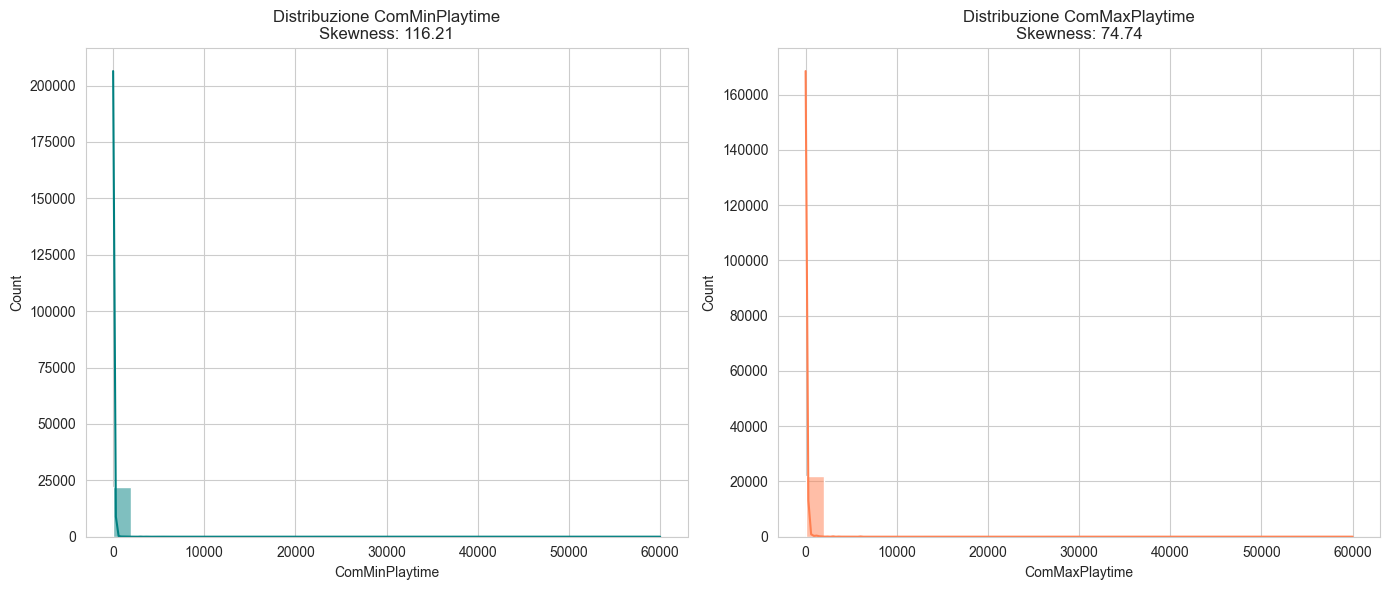


--- TEST TRASFORMAZIONE LOGARITMICA (log1p) ---
Skewness ComMinPlaytime (Log): -0.6780
Skewness ComMaxPlaytime (Log): -0.7006


In [18]:
# 1. Calcolo numerico della Skewness originale
skew_com_min = df['ComMinPlaytime'].skew()
skew_com_max = df['ComMaxPlaytime'].skew()

print(f"--- ANALISI SKEWNESS ORIGINALE ---")
print(f"ComMinPlaytime: {skew_com_min:.4f}")
print(f"ComMaxPlaytime: {skew_com_max:.4f}")

# 2. Visualizzazione Grafica delle distribuzioni originali
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['ComMinPlaytime'], kde=True, color='teal', bins=30)
plt.title(f'Distribuzione ComMinPlaytime\nSkewness: {skew_com_min:.2f}')

plt.subplot(1, 2, 2)
sns.histplot(df['ComMaxPlaytime'], kde=True, color='coral', bins=30)
plt.title(f'Distribuzione ComMaxPlaytime\nSkewness: {skew_com_max:.2f}')

plt.tight_layout()
plt.show()

# 3. Test rapido: la trasformazione logaritmica aiuta?
print(f"\n--- TEST TRASFORMAZIONE LOGARITMICA (log1p) ---")
print(f"Skewness ComMinPlaytime (Log): {np.log1p(df['ComMinPlaytime']).skew():.4f}")
print(f"Skewness ComMaxPlaytime (Log): {np.log1p(df['ComMaxPlaytime']).skew():.4f}")

In [19]:
# print rows where ComMinPlaytime and ComMaxPlaytime are both 0
df[(df['ComMinPlaytime'] == 0) & (df['ComMaxPlaytime'] == 0)]


,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories
6,25841,Le Grand Empire,le grand empire simulate napoleonic war st...,2007,3.7000,3.8964,2,7,NaN,388.0,...,0,0,1,0,0,0,0,0,High,1
112,14705,Totally Gross,publisherwant help kid understand chemistry bi...,2002,1.4000,1.5393,2,4,8.0,5.0,...,0,0,0,0,0,0,0,1,Low,1
116,19378,Doctor Who: The Interactive Electronic Board Game,base seasonquotyou doctor travel space colle...,2005,1.4286,1.5444,2,6,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0
135,73536,The Chinese Civil War of 1930,china complete unity warlord grasp real poli...,2010,2.8333,2.9672,2,5,8.0,474.0,...,0,0,1,0,0,0,0,0,Medium,1
154,15542,Orangino,publisher websiteorangino parlor game social g...,2002,1.0000,1.2483,2,6,NaN,NaN,...,0,0,0,0,0,0,0,0,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21790,22674,Mława 1939,battle mlawa battle occur northern mazowsze ...,1999,3.0000,3.1347,2,2,16.0,8.0,...,0,0,1,0,0,0,0,0,Low,1
21812,167505,Star Wars Force Grab,fastaction family game kid adult ldquouse forc...,2014,1.2000,1.3904,2,6,3.0,251.0,...,0,0,0,0,0,0,0,0,Low,0
21817,139390,Perplexus Twist,perplexus twist new d maze game player maneuve...,2013,2.0000,2.1270,1,1,NaN,NaN,...,0,0,0,0,0,0,0,0,Medium,0
21837,19272,Go Fish!,watch preschooler hook fishy card game color...,1997,1.0000,1.2513,2,4,NaN,NaN,...,0,0,0,0,0,0,0,1,Low,1


In [20]:
df[['MfgAgeRec','ComAgeRec']].describe()

# no negative numbers
# 0 might be invalid or represent missing data

,MfgAgeRec,ComAgeRec
count,21925.000000,16395.000000
mean,9.613409,10.004391
std,3.641560,3.269157
min,0.000000,2.000000
25%,8.000000,8.000000
50%,10.000000,10.000000
75%,12.000000,12.000000
max,25.000000,21.000000


In [21]:
# 1. GameWeight < 1
count_gameweight_lt1 = len(df[df['GameWeight'] < 1])
print(f"Number of records with GameWeight < 1: {count_gameweight_lt1}")

# 2. GameWeight > 5
count_gameweight_gt5 = len(df[df['GameWeight'] > 5])
print(f"Number of records with GameWeight > 5: {count_gameweight_gt5}")

# 3. ComWeight < 1
count_comweight_lt1 = len(df[df['ComWeight'] < 1])
print(f"Number of records with ComWeight < 1: {count_comweight_lt1}")

# 4. ComWeight > 5
count_comweight_gt5 = len(df[df['ComWeight'] > 5])
print(f"Number of records with ComWeight > 5: {count_comweight_gt5}")

Number of records with GameWeight < 1: 506
Number of records with GameWeight > 5: 0
Number of records with ComWeight < 1: 506
Number of records with ComWeight > 5: 13


In [22]:
# Ranks should be positive numbers. Negative or zero ranks could indicate errors.
rank_cols = [c for c in df.columns if c.startswith('Rank:')]
df[(df[rank_cols] <= 0).any(axis=1)]

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories


#### Questa inconsistency non è valida perchè probabilmente i giochi sono stati finanziati dopo la pubblicazione.

In [23]:
# Kickstarter started in 2009 — games marked as kickstarted before that are inconsistent.
# Kickstarter was founded in 2009

anomalous_kickstarted_games = df[(df['Kickstarted'] == 1) & (df['YearPublished'] < 2009)]
num_anomalies = len(anomalous_kickstarted_games)

print(f"Number of 'Kickstarted' anomalies (published before 2009): {num_anomalies}")

# Display the resulting DataFrame containing the anomalies (optional, but helpful for inspection)
# anomalous_kickstarted_games
print("List of anomalous 'Kickstarted' games published before 2009:")
a = anomalous_kickstarted_games[['Name', 'YearPublished', 'Kickstarted']]
a

Number of 'Kickstarted' anomalies (published before 2009): 83
List of anomalous 'Kickstarted' games published before 2009:


,Name,YearPublished,Kickstarted
880,Alquerque,1000,1
1188,The Cones of Dunshire,0,1
1293,Barca,2007,1
1496,Evil Dead 2: The Official Board Game,0,1
1624,War Titans: Invaders Must Die!,0,1
...,...,...,...
21109,Corsair Leader,2005,1
21264,Hoyuk,2006,1
21495,Metro,1997,1
21555,Moonstone,0,1


### Outliers

#### YearPublished

In [24]:
df["YearPublished"].describe()

count    21925.000000
mean      1985.494914
std        212.486214
min      -3500.000000
25%       2001.000000
50%       2011.000000
75%       2017.000000
max       2021.000000
Name: YearPublished, dtype: float64

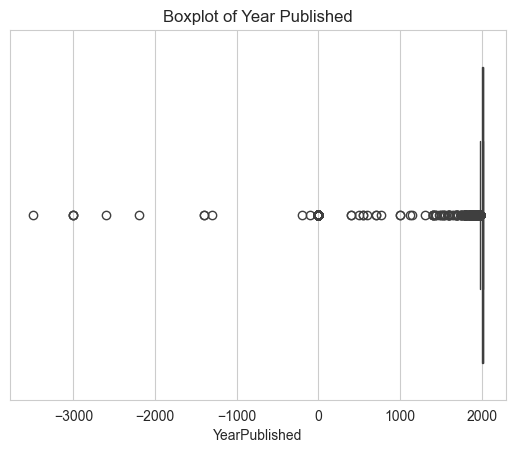

In [25]:
sns.boxplot(x=df['YearPublished'])
plt.title("Boxplot of Year Published")
plt.show()

In [26]:
df_ancient = df[df['YearPublished'] < 1900]
print("Games published before 1900:", df_ancient.shape[0])

df_modern = df[df['YearPublished'] >= 1900]
print("Games published after 1900:", df_modern.shape[0])


Games published before 1900: 309
Games published after 1900: 21616


In [27]:
df_ancient['YearPublished'].describe()

count     309.000000
mean      480.213592
std       946.057290
min     -3500.000000
25%         0.000000
50%         0.000000
75%      1550.000000
max      1899.000000
Name: YearPublished, dtype: float64

In [28]:
df_modern['YearPublished'].describe()

count    21616.000000
mean      2007.012861
std         13.682522
min       1900.000000
25%       2002.000000
50%       2012.000000
75%       2017.000000
max       2021.000000
Name: YearPublished, dtype: float64

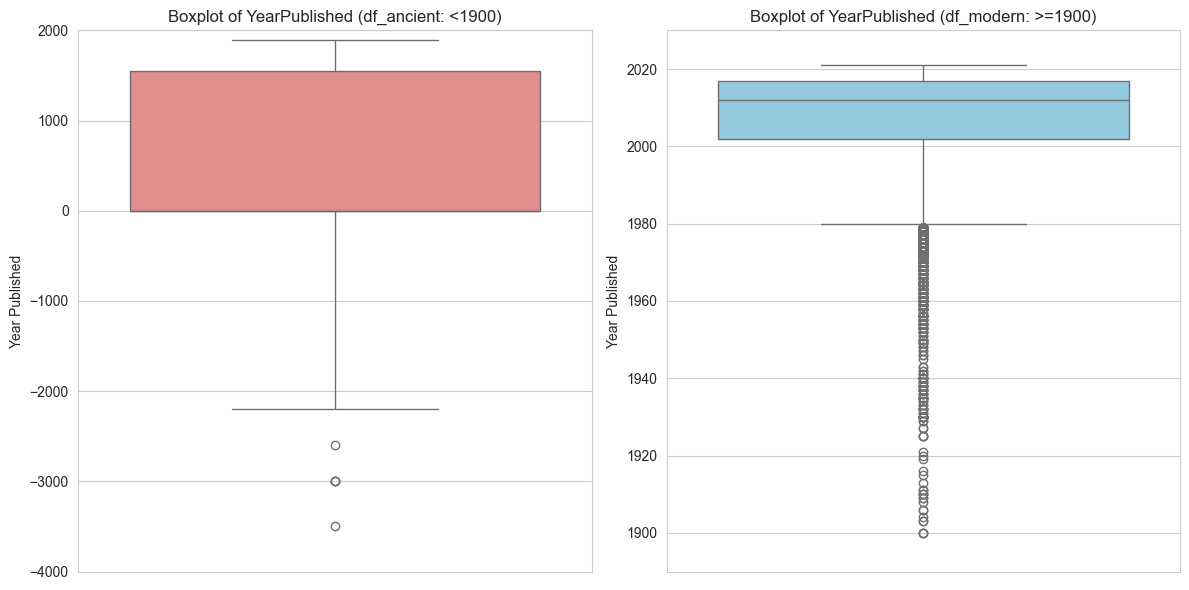

In [29]:
# Create the figure and axes for the side-by-side boxplots
plt.figure(figsize=(12, 6))

# --- Boxplot for df_ancient (Pre-1900 games) ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(y=df_ancient['YearPublished'], color='lightcoral')
plt.title('Boxplot of YearPublished (df_ancient: <1900)')
plt.ylabel('Year Published')
# Set wide limits to capture extreme outliers like -3500 and 0
plt.ylim(ymin=-4000, ymax=2000) 

# --- Boxplot for df_modern (1900 and later games) ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=df_modern['YearPublished'], color='skyblue')
plt.title('Boxplot of YearPublished (df_modern: >=1900)')
plt.ylabel('Year Published')
# Set tighter limits for clear visualization of the modern distribution
plt.ylim(ymin=1890, ymax=2030) 

plt.tight_layout() # Optimize subplot spacing
plt.show()

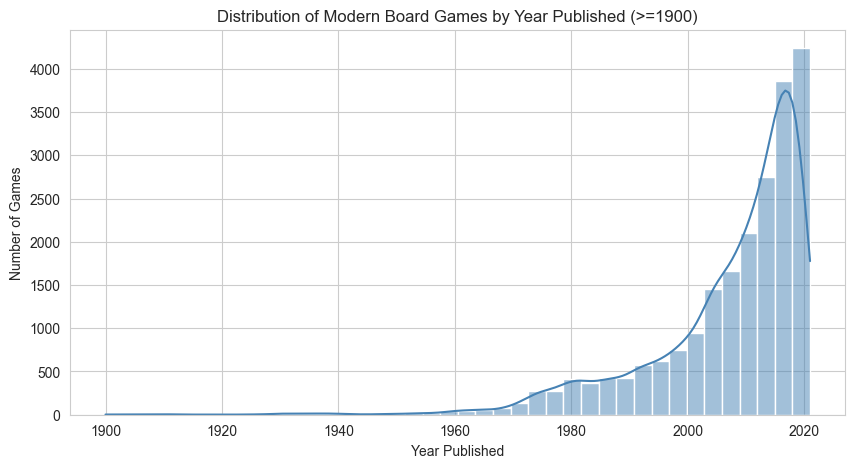

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(df_modern['YearPublished'], bins=40, kde=True, color='steelblue')
plt.title("Distribution of Modern Board Games by Year Published (>=1900)")
plt.xlabel("Year Published")
plt.ylabel("Number of Games")
plt.show()

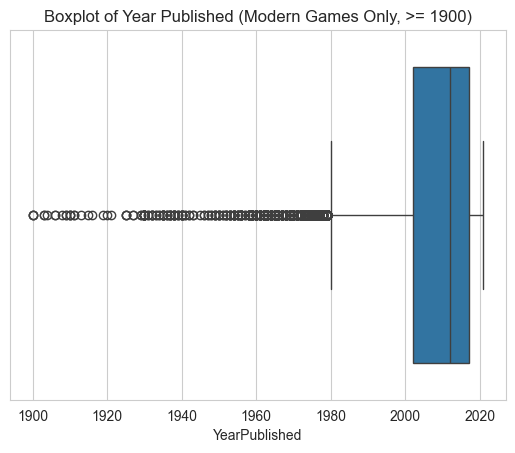

In [31]:
sns.boxplot(x=df_modern['YearPublished'])
plt.title("Boxplot of Year Published (Modern Games Only, >= 1900)")
plt.show()

# games published between 1900 and 1980 are identified as outliers.
# This is due to the majority of modern games being released after 1980, particularly in the 2000s.

In [32]:
# Count the number of games for each year in the modern subset (df_modern)
yearly_counts = df_modern['YearPublished'].value_counts().sort_index()

print("--- Number of Games Published Per Year (Since 1900) ---")
print(yearly_counts)

--- Number of Games Published Per Year (Since 1900) ---
YearPublished
1900       3
1903       2
1904       1
1906       2
1908       1
        ... 
2017    1356
2018    1351
2019    1302
2020     927
2021     660
Name: count, Length: 108, dtype: int64


#### MfgPlaytime, ComMinPlaytime, ComMaxPlaytime

In [33]:
# Display descriptive statistics for playtime-related features
# This helps identify potential anomalies such as unusually large or zero values
df[['MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']].describe()

,MfgPlaytime,ComMinPlaytime,ComMaxPlaytime
count,21925.000000,21925.000000,21925.000000
mean,90.513523,63.678586,90.513523
std,529.657389,443.916212,529.657389
min,0.000000,0.000000,0.000000
25%,25.000000,20.000000,25.000000
50%,45.000000,30.000000,45.000000
75%,90.000000,60.000000,90.000000
max,60000.000000,60000.000000,60000.000000


In [34]:
# Inspect the specific record at index 4349
# This game shows extreme playtime values (60,000 minutes), which correspond
# to a title with theoretically unlimited duration according to external sources (e.g., Wikipedia)
df.loc[4349, ['Name', 'MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime']]

Name              The Campaign for North Africa: The Desert War ...
MfgPlaytime                                                   60000
ComMinPlaytime                                                60000
ComMaxPlaytime                                                60000
Name: 4349, dtype: object

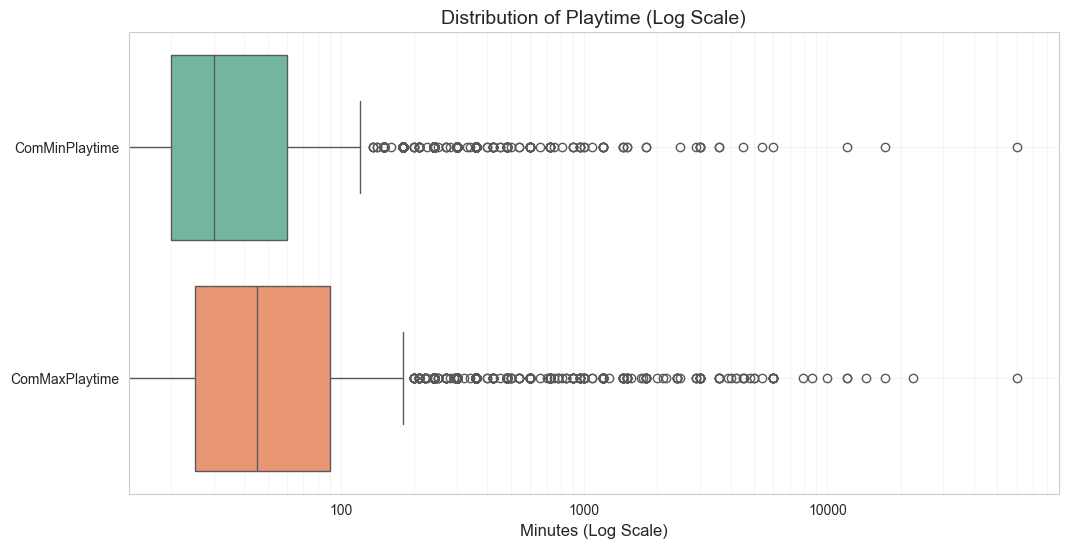

In [35]:
plt.figure(figsize=(12, 6))

# 1. Crea il Boxplot orizzontale
sns.boxplot(data=df[['ComMinPlaytime', 'ComMaxPlaytime']], orient='h', palette='Set2')

# 2. APPLICA LA SCALA LOGARITMICA ALL'ASSE X
plt.xscale('log')

# 3. Formattazione per rendere i numeri leggibili (es. 10, 100 invece di 10^1, 10^2)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.title('Distribution of Playtime (Log Scale)', fontsize=14)
plt.xlabel('Minutes (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2) # Aggiunge una griglia leggera

plt.show()

### **3. Numerical features analysis**

#### GameWeight & ComWeight

In [36]:
print(df[['GameWeight', 'ComWeight']].describe())
print("\n")

         GameWeight     ComWeight
count  21925.000000  21925.000000
mean       1.982131      2.177479
std        0.848983      0.861781
min        0.000000      0.000000
25%        1.333300      1.513400
50%        1.968800      2.128000
75%        2.525200      2.737700
max        5.000000      5.213200




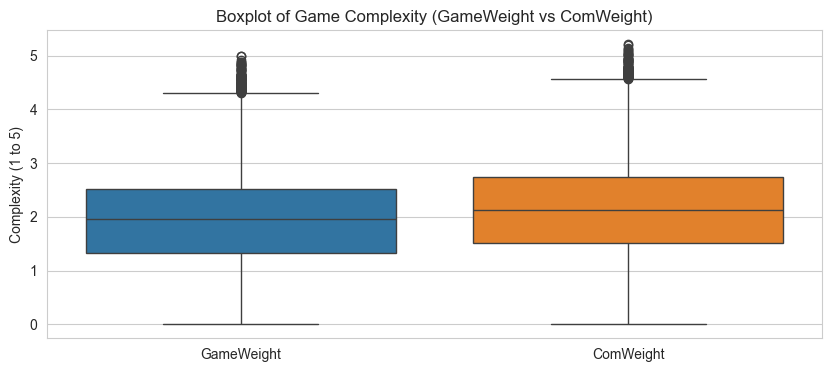

In [37]:
#Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[['GameWeight', 'ComWeight']])
plt.title("Boxplot of Game Complexity (GameWeight vs ComWeight)")
plt.ylabel("Complexity (1 to 5)")
plt.show()

In [38]:
corr = df[['GameWeight', 'ComWeight']].corr().iloc[0, 1]            #compute correlation
print(f"Correlation between GameWeight and ComWeight: {corr:.4f}")

Correlation between GameWeight and ComWeight: 0.9973


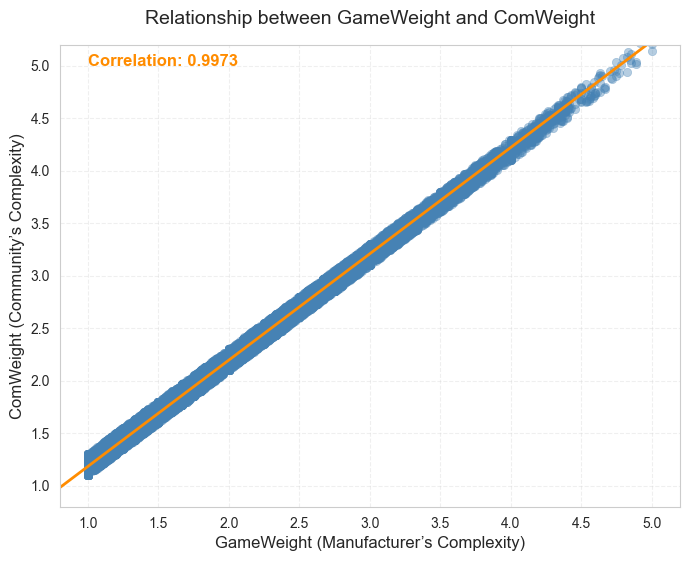

In [39]:
plt.figure(figsize=(8, 6))          #visualize correlation
sns.set_style("whitegrid")

sns.scatterplot(
    data=df,
    x='GameWeight',
    y='ComWeight',
    alpha=0.4,
    color='steelblue',
    edgecolor=None
)

# Regression line
sns.regplot(
    data=df,
    x='GameWeight',
    y='ComWeight',
    scatter=False,
    color='darkorange',
    line_kws={'linewidth': 2}
)

# Add correlation text
plt.text(
    1.0, 5.0,
    f"Correlation: {corr:.4f}",
    fontsize=12,
    color='darkorange',
    fontweight='bold'
)

# Formatting
plt.title('Relationship between GameWeight and ComWeight', fontsize=14, pad=15)
plt.xlabel("GameWeight (Manufacturer’s Complexity)", fontsize=12)
plt.ylabel("ComWeight (Community’s Complexity)", fontsize=12)
plt.xlim(0.8, 5.2)
plt.ylim(0.8, 5.2)
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

#### GameWeight & NumWeightVotes

In [40]:
# 1. Create Mask A: Rows where GameWeight is 0
mask_A = (df['GameWeight'] == 0.0)
num_zero_weight = mask_A.sum()

# 2. Create Mask B: Rows where NumWeightVotes is zero
mask_B = (df['NumWeightVotes'] == 0)
num_zero_votes = mask_B.sum()

# 3. Check 1: Are the zero values in GameWeight an exact subset of zero votes?
are_they_identical = (mask_A == mask_B).all()

# 4. Check 2: Find rows violating the condition (XOR operation)
violations = df[mask_A ^ mask_B]

print(f"Rows where GameWeight = 0: {num_zero_weight}")
print(f"Rows with NumWeightVotes = 0: {num_zero_votes}")
print("-" * 50)

if are_they_identical:
    print("Result: The two conditions are IDENTICAL for ALL rows.")
    print("The hypothesis is confirmed: Zero GameWeight values are solely caused by the absence of votes.")
else:
    print("Result: The two conditions are NOT identical (violations found).")
    print(f"Number of rows where A and B differ: {len(violations)}")
    
    # Print the first 5 anomalous cases for inspection
    if not violations.empty:
        print("\nFirst 5 violation cases:")
        print(violations[['Name', 'GameWeight', 'NumWeightVotes']].head())

Rows where GameWeight = 0: 506
Rows with NumWeightVotes = 0: 506
--------------------------------------------------
Result: The two conditions are IDENTICAL for ALL rows.
The hypothesis is confirmed: Zero GameWeight values are solely caused by the absence of votes.


#### LanguageEase

In [41]:
df["LanguageEase"].describe()

count    16034.000000
mean       216.461819
std        236.595136
min          1.000000
25%         24.027778
50%        138.000000
75%        351.000000
max       1757.000000
Name: LanguageEase, dtype: float64

In [42]:
#correlazione tra LanguageEase e GameWeight
corr = df[['LanguageEase', 'GameWeight']].corr().iloc[0,1]
print(f"Correlation between LanguageEase and GameWeight: {corr:.4f}")

corr = df[['LanguageEase', 'GameWeight']].corr(method="spearman").iloc[0,1]
print(f"Spearman correlation between LanguageEase and GameWeight: {corr:.4f}")

corr = df[['LanguageEase', 'GameWeight']].corr(method="kendall").iloc[0,1]
print(f"Kendall correlation between LanguageEase and GameWeight: {corr:.4f}")

# Non esiste alcuna correlazione significativa (né lineare né monotona) tra LanguageEase e GameWeight.
# In altre parole, la facilità linguistica non sembra avere alcuna relazione con il peso del gioco nei tuoi dati.

Correlation between LanguageEase and GameWeight: -0.0081
Spearman correlation between LanguageEase and GameWeight: -0.0348
Kendall correlation between LanguageEase and GameWeight: -0.0233


#### YearPublished

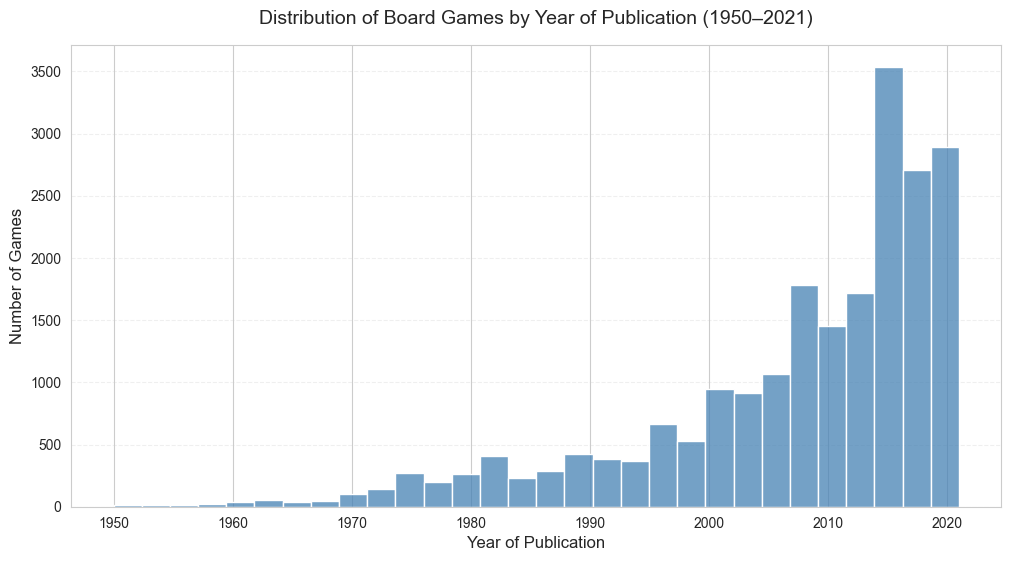

In [43]:
# --- Filter dataset for modern board games ---
df_modern = df[(df['YearPublished'] >= 1950) & (df['YearPublished'] <= 2021)]

# --- Plot histogram ---
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_modern,
    x='YearPublished',
    bins=30,          # number of bins for decade-level granularity
    color='steelblue',
    kde=False
)

# --- Add titles and labels ---
plt.title('Distribution of Board Games by Year of Publication (1950–2021)', fontsize=14, pad=15)
plt.xlabel('Year of Publication', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

### YearPublished & Kickstarter

In [44]:
# Filter the DataFrame to include only years from 2009 onwards (Kickstarter foundation year)
df_post_2009 = df[df['YearPublished'] >= 2009].copy()

# Group and calculate annual statistics
yearly_stats = df_post_2009.groupby('YearPublished').agg(
    TotalGames=('Name', 'count'),
    KickstartedGames=('Kickstarted', 'sum') # The sum of the binary variables gives the count
).reset_index()

# Calculate the percentage of crowdfunded games out of the annual total
yearly_stats['Crowdfunding_Share'] = (yearly_stats['KickstartedGames'] / yearly_stats['TotalGames']) * 100

print("Annual Crowdfunding Data (since 2009):")
print(yearly_stats)

Annual Crowdfunding Data (since 2009):
    YearPublished  TotalGames  KickstartedGames  Crowdfunding_Share
0            2009         647                12            1.854714
1            2010         710                21            2.957746
2            2011         746                47            6.300268
3            2012         843               117           13.879004
4            2013         875               221           25.257143
5            2014        1032               327           31.686047
6            2015        1185               385           32.489451
7            2016        1321               399           30.204391
8            2017        1356               364           26.843658
9            2018        1351               412           30.495929
10           2019        1302               391           30.030722
11           2020         927               294           31.715210
12           2021         660               289           43.787879


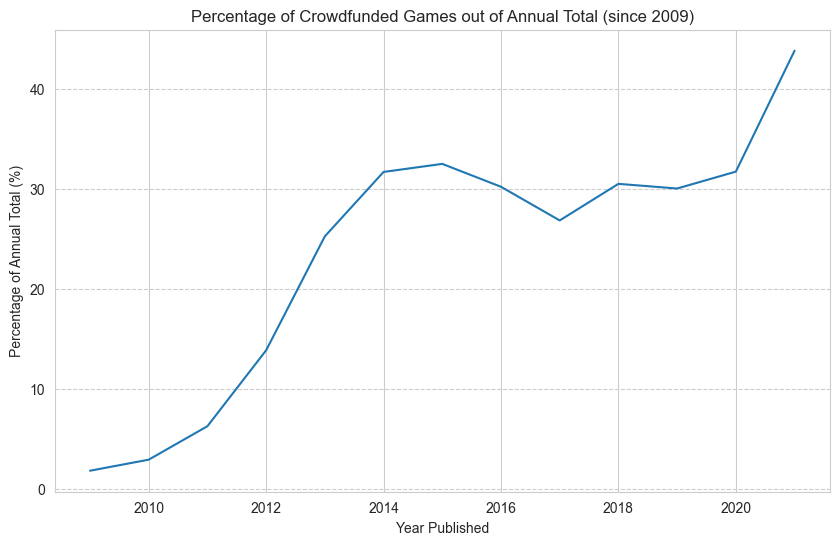

In [45]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='YearPublished', 
    y='Crowdfunding_Share', 
    data=yearly_stats
)
plt.title('Percentage of Crowdfunded Games out of Annual Total (since 2009)')
plt.ylabel('Percentage of Annual Total (%)')
plt.xlabel('Year Published')
plt.grid(axis='y', linestyle='--')
plt.show()

In [46]:
# correlation between 'Kickstarted' and 'YearPublished' for games published from 2009 onwards
correlation_results = df_post_2009[['Kickstarted', 'YearPublished']].corr()
    
print(correlation_results.loc['Kickstarted', ['YearPublished']])

YearPublished    0.214033
Name: Kickstarted, dtype: float64


#### MfgAgeRec & ComAgeRec

In [47]:
df[['MfgAgeRec', 'ComAgeRec']].describe()

,MfgAgeRec,ComAgeRec
count,21925.000000,16395.000000
mean,9.613409,10.004391
std,3.641560,3.269157
min,0.000000,2.000000
25%,8.000000,8.000000
50%,10.000000,10.000000
75%,12.000000,12.000000
max,25.000000,21.000000


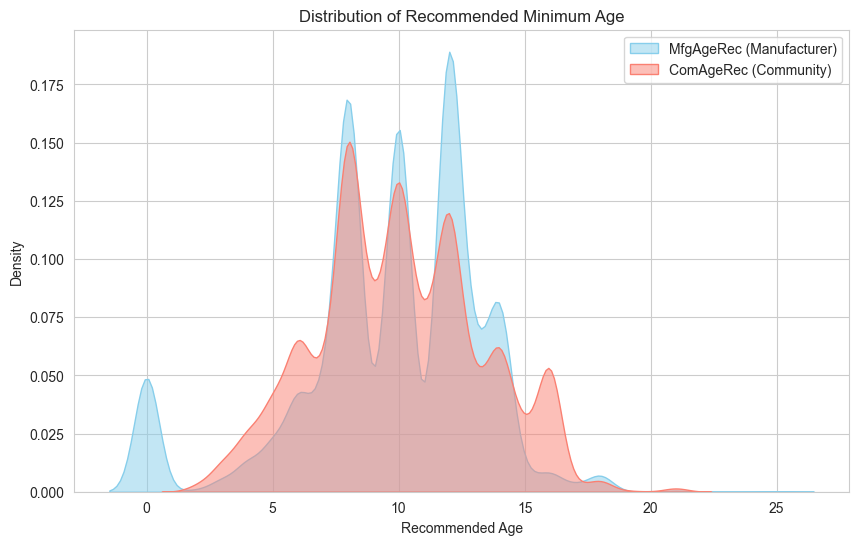

In [48]:
# KDE plot

plt.figure(figsize=(10, 6))
sns.kdeplot(df['MfgAgeRec'], fill=True, color='skyblue', alpha=0.5, label='MfgAgeRec (Manufacturer)')
sns.kdeplot(df['ComAgeRec'], fill=True, color='salmon', alpha=0.5, label='ComAgeRec (Community)')

plt.title('Distribution of Recommended Minimum Age')
plt.xlabel('Recommended Age')
plt.ylabel('Density')
plt.legend()
plt.show()

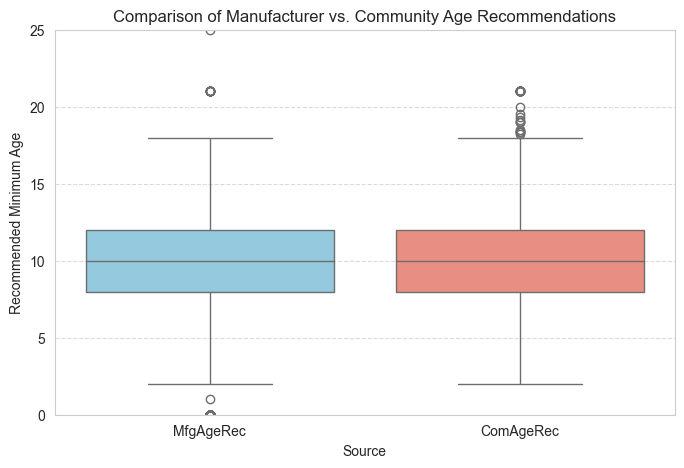

In [49]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['MfgAgeRec', 'ComAgeRec']], palette=['skyblue', 'salmon'])
plt.title('Comparison of Manufacturer vs. Community Age Recommendations')
plt.ylabel('Recommended Minimum Age')
plt.xlabel('Source')
plt.ylim(0, 25)  # focus on realistic values
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [50]:
corr = df[['MfgAgeRec', 'ComAgeRec']].corr().iloc[0,1]
print(f"Correlation between MfgAgeRec and ComAgeRec: {corr:.3f}")

#correlazione che non tiene conto del fatto che ComAgeRec contenga molti zeri

Correlation between MfgAgeRec and ComAgeRec: 0.433


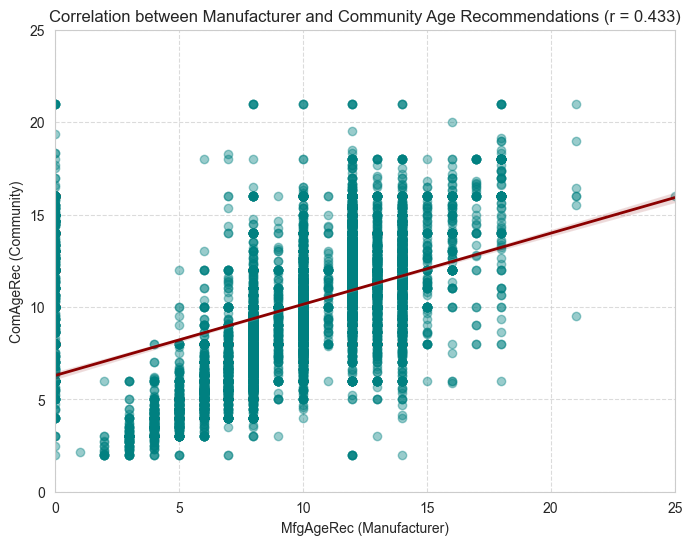

In [51]:
#visualize correlation
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))

# --- Scatterplot with regression line ---
sns.regplot(
    data=df,
    x='MfgAgeRec',
    y='ComAgeRec',
    scatter_kws={'alpha': 0.4, 'color': 'teal'},
    line_kws={'color': 'darkred', 'lw': 2},
)

# Add labels and title
plt.title(f'Correlation between Manufacturer and Community Age Recommendations (r = {corr:.3f})')
plt.xlabel('MfgAgeRec (Manufacturer)')
plt.ylabel('ComAgeRec (Community)')
plt.grid(True, linestyle='--', alpha=0.7)

# Optional: set reasonable axis limits
plt.xlim(0, 25)
plt.ylim(0, 25)

plt.show()

#### NumOwned, NumWant, NumWish, NumUserRatings, NumComments 

In [52]:
print(df[['NumOwned', 'NumWant','NumWish','NumUserRatings', 'NumComments']].describe())
print("\n")

            NumOwned       NumWant       NumWish  NumUserRatings  NumComments
count   21925.000000  21925.000000  21925.000000    21925.000000      21925.0
mean     1467.848164     41.690946    228.457013      861.668324          0.0
std      5294.120574    117.255229    788.477151     3638.680857          0.0
min         0.000000      0.000000      0.000000       30.000000          0.0
25%       150.000000      3.000000     14.000000       56.000000          0.0
50%       320.000000      9.000000     39.000000      123.000000          0.0
75%       899.000000     28.000000    127.000000      395.000000          0.0
max    166497.000000   2031.000000  19182.000000   108101.000000          0.0




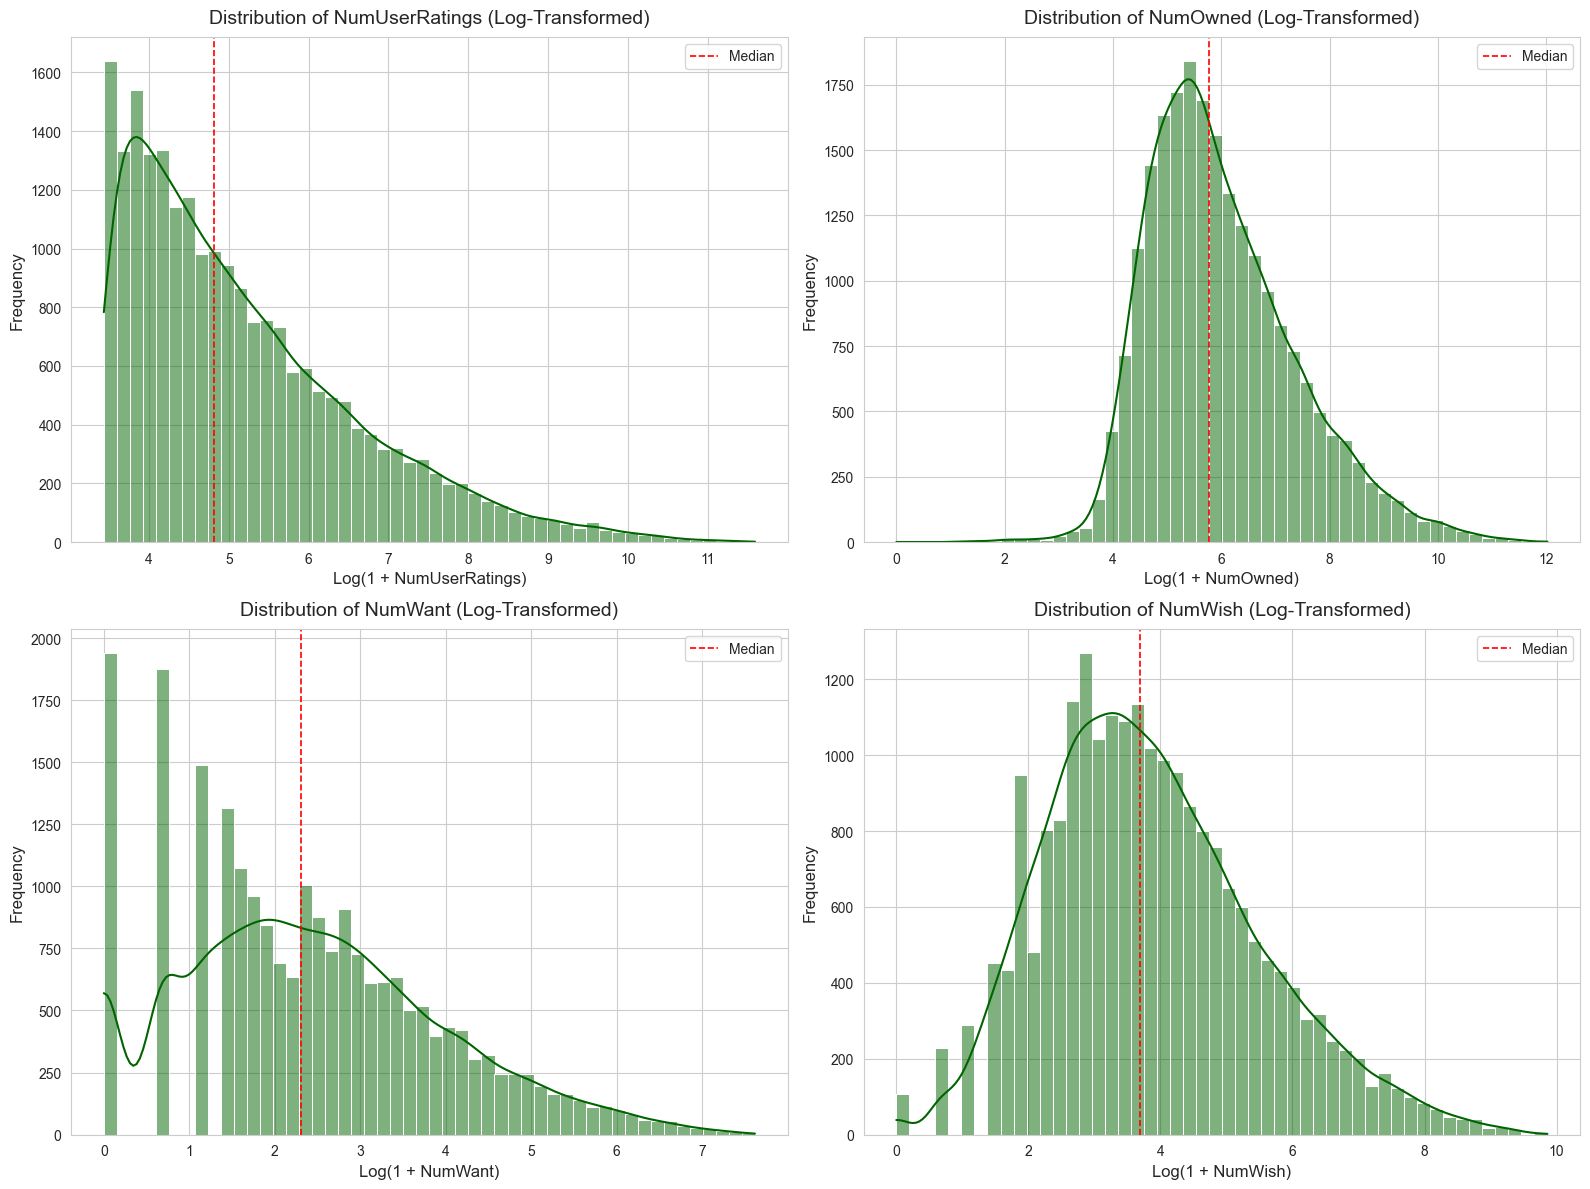

In [53]:
# Visualization

# Set a clean visual style
sns.set_style("whitegrid")

# Features representing game popularity and engagement
popularity_features = ['NumUserRatings', 'NumOwned', 'NumWant', 'NumWish']

# Create a figure with four subplots (2 rows × 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, feature in enumerate(popularity_features):
    # Apply log(1 + X) transformation to handle extreme skewness
    log_data = np.log1p(df[feature])
    
    # Plot histogram with KDE overlay
    sns.histplot(
        x=log_data,
        bins=50,
        color='darkgreen',
        ax=axes[i],
        kde=True
    )
    
    # Add median reference line
    axes[i].axvline(log_data.median(), color='red', linestyle='--', linewidth=1.2, label='Median')
    
    # Titles and labels
    axes[i].set_title(f'Distribution of {feature} (Log-Transformed)', fontsize=14, pad=10)
    axes[i].set_xlabel(f'Log(1 + {feature})', fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].legend()

# Adjust layout for better readability
plt.tight_layout()
plt.show()


In [54]:
#correlazione tra NumWant e NumWish
corr = df[['NumWant', 'NumWish']].corr().iloc[0,1]
print(f"Correlation between NumWant and NumWish: {corr:.4f}")

Correlation between NumWant and NumWish: 0.9398


### **4. Categorical features analysis**

#### BestPlayers & GoodPlayers

- 'BestPlayers' represents the single best number of players for a game,
-  'GoodPlayers' is a list (array) of community-recommended player counts.

In [55]:
print(df['BestPlayers'].dtype)
print(type(df['GoodPlayers'].iloc[0]))

int64
<class 'str'>


In [56]:
# 1. Check how many entries in 'BestPlayers' are zero
best_players = df["BestPlayers"]
num_of_0 = (best_players == 0).sum()
perc_of_0 = (num_of_0 / len(best_players)) * 100
print(f"Percentage of 0 values in BestPlayers: {perc_of_0:.2f}%")

# 2. Check how many entries in 'GoodPlayers' are empty arrays
good_players = df["GoodPlayers"]
num_empty_arrays = (good_players == "[]").sum()
perc_empty_arrays = (num_empty_arrays / len(good_players)) * 100
print(f"Percentage of empty arrays in GoodPlayers: {perc_empty_arrays:.2f}%")

# 3. Display the two columns for a quick structural check
df[["BestPlayers", "GoodPlayers"]]

# Observation:
# More than 90% of 'BestPlayers' are zeros and 'GoodPlayers' contain empty arrays.
# This suggests that these features have limited informational value
# and may represent missing or incomplete data.

Percentage of 0 values in BestPlayers: 90.96%
Percentage of empty arrays in GoodPlayers: 90.97%


,BestPlayers,GoodPlayers
0,0,[]
1,0,[]
2,0,[]
3,0,[]
4,0,[]
...,...,...
21920,0,[]
21921,0,[]
21922,0,[]
21923,0,[]


#### Rating

In [57]:
df['Rating'].value_counts()

Rating
Medium    9644
Low       7245
High      5036
Name: count, dtype: int64

In [58]:
rating_counts=df['Rating'].value_counts(normalize=True) * 100  # Percentage
print(rating_counts)

Rating
Medium    43.986317
Low       33.044470
High      22.969213
Name: proportion, dtype: float64


C:\Users\elisa\AppData\Local\Temp\ipykernel_24076\3787096833.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', order=rating_counts.index, palette='viridis')


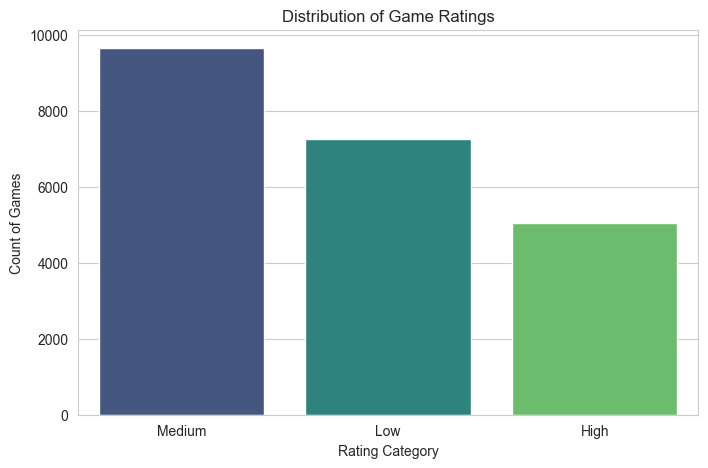

In [59]:
# Visualize distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Rating', order=rating_counts.index, palette='viridis')

plt.title('Distribution of Game Ratings')
plt.xlabel('Rating Category')
plt.ylabel('Count of Games')
plt.show()

#### Family

In [60]:
top20_families = df['Family'].value_counts().head(20)
print("\nTop 20 Game Families:\n", top20_families)


Top 20 Game Families:
 Family
18xx                                         103
Monopoly (Official)                           73
Trivial Pursuit                               67
Werewolf / Mafi                               58
Wallet Games (Button Shy)                     45
Two-player games (Kosmos)                     44
Cluedo / Clue (Parker Brothers, et al)        42
Munchkin                                      41
Monopoly-Lik                                  39
UNO                                           39
Fluxx                                         38
LEGO Gam                                      34
Catan                                         34
Fantasy Flight Silver Lin                     32
Risk (Official)                               32
Cube Rail                                     31
Anno Domini                                   29
NSV Middys (Nürnberger Spielkartenverlag)     29
Unlock! (Space Cowboys)                       29
Exit – The Gam                        

C:\Users\elisa\AppData\Local\Temp\ipykernel_24076\3339545675.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


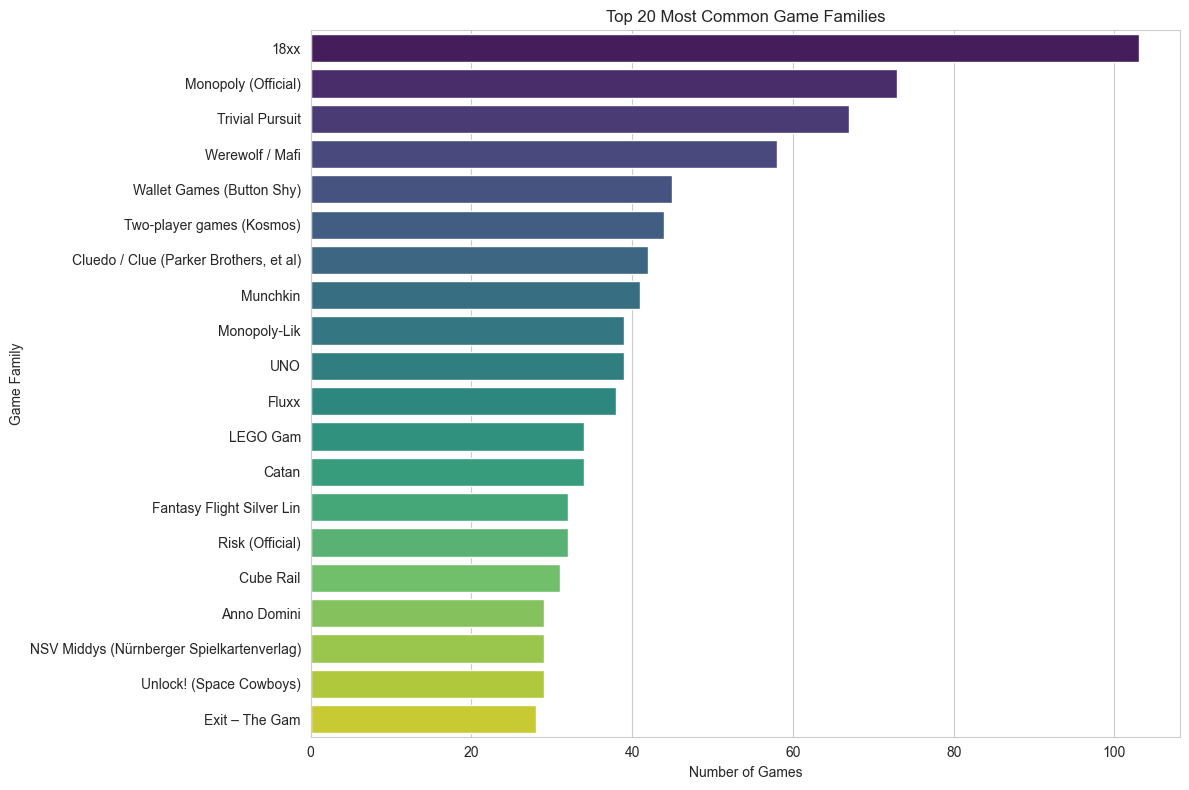


Percentage of missing values in Family: 69.61%


In [61]:
# Visualization of the distribution
plt.figure(figsize=(12, 8))
sns.barplot(
    x=top20_families.values,
    y=top20_families.index,
    palette='viridis'
)

plt.title('Top 20 Most Common Game Families')
plt.xlabel('Number of Games')
plt.ylabel('Game Family')
plt.tight_layout()
plt.show()

# Missing values analysis
total_rows = len(df)
missing_ratio = (df['Family'].isnull().sum() / total_rows) * 100
print(f"\nPercentage of missing values in Family: {missing_ratio:.2f}%")

# Most games do not have a recorded Family value (around 70% missing).
# The distribution is heavily right-skewed, with a few popular families dominating.
# This feature could be used for categorical analysis, but rare categories may need to be grouped as 'Other'.

#### Kickstarted

In [62]:
# Check how many 0s and 1s are in Kickstarted
number_of_ones = df['Kickstarted'].value_counts().get(1, 0)
print(f"The number of occurrences with value 1 in the Kickstarted column is: {number_of_ones}")
number_of_zeros = df['Kickstarted'].value_counts().get(0, 0)
print(f"The number of occurrences with value 0 in the Kickstarted column is: {number_of_zeros}")
number_of_ones + number_of_zeros

The number of occurrences with value 1 in the Kickstarted column is: 3362
The number of occurrences with value 0 in the Kickstarted column is: 18563


np.int64(21925)

#### Cat features

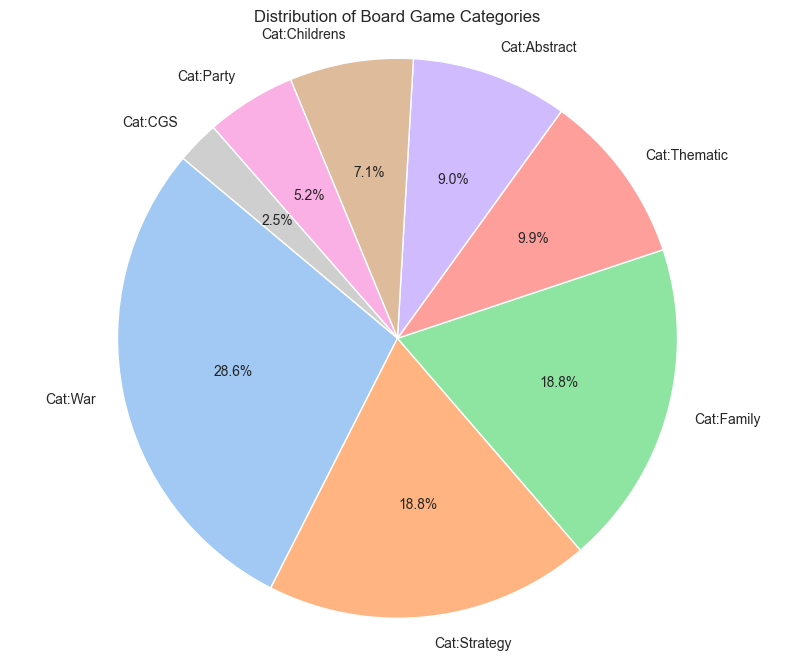

In [63]:
# create a pie chart to visualize the distribution of Category features
category_features = [col for col in df.columns if col.startswith('Cat:')]
category_sums = df[category_features].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
plt.pie(
    category_sums,
    labels=category_sums.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')[0:len(category_sums)]
)
plt.title('Distribution of Board Game Categories')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


C:\Users\elisa\AppData\Local\Temp\ipykernel_24076\3020910261.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sums.index, y=category_sums.values, palette='pastel')


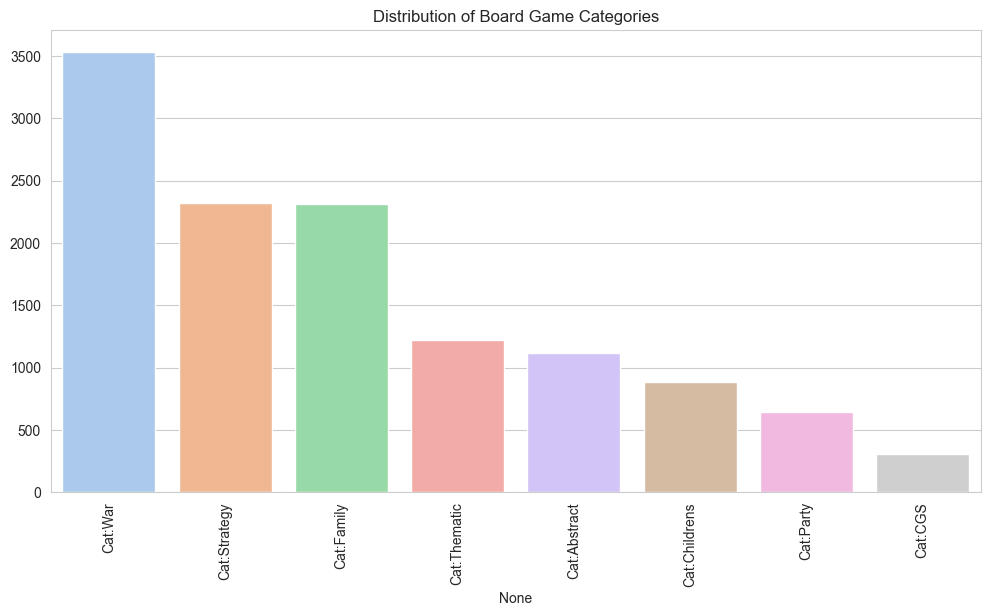

In [64]:
# create also a histogram for category features
plt.figure(figsize=(12, 6))
sns.barplot(x=category_sums.index, y=category_sums.values, palette='pastel')
plt.xticks(rotation=90)
plt.title('Distribution of Board Game Categories')
plt.show()


#### Cat and Rank Features

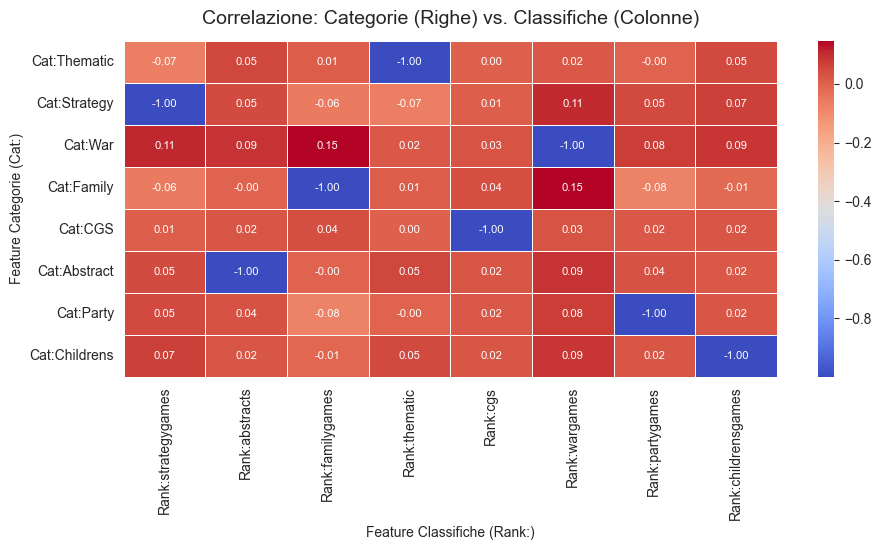

In [65]:
cat_features = [col for col in df.columns if col.startswith('Cat:')]
rank_features = [col for col in df.columns if col.startswith('Rank:')]

cat_df = df[cat_features]
rank_df = df[rank_features]

combined_df = pd.concat([cat_df, rank_df], axis=1)

full_corr_matrix = combined_df.corr()

corr_matrix_cat_vs_rank = full_corr_matrix.loc[cat_features, rank_features]

plt.figure(figsize=(len(rank_features) * 1.2, len(cat_features) * 0.7))
sns.set_style("whitegrid")
sns.heatmap(
    corr_matrix_cat_vs_rank,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=False,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Correlazione: Categorie (Righe) vs. Classifiche (Colonne)", fontsize=14, pad=12)
plt.ylabel('Feature Categorie (Cat:)', fontsize=10)
plt.xlabel('Feature Classifiche (Rank:)', fontsize=10)
plt.tight_layout()
plt.show()

Verifico se GameWeight, MinPlayers, MaxPlayers, ComAgeRec, LanguageEase, ComMinPlaytime e ComMaxPlaytime variano molto in base alla categoria o no. Se sì, l'imputazione con moda/mediana può essere fatta in base a media/mediana della categoria. Altrimenti si usa la media/mediana globale

In [66]:
# Elenco delle variabili numeriche da testare (le tue variabili dipendenti)
VARIABILI_NUMERICHE = [
    'GameWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 
    'LanguageEase', 'ComMinPlaytime', 'ComMaxPlaytime'
]

# Elenco delle colonne delle categorie (le tue variabili binarie indipendenti)
# Usa i nomi delle colonne esattamente come sono nel tuo DataFrame
CATEGORIE = [
    'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 
    'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens' 
]

In [67]:
# Livello di significatività (alfa): se p-value < 0.05, c'è una differenza significativa
ALFA = 0.05

# --- FUNZIONE DI ANALISI ---

def verifica_variazione_categoria(df, variabili_num, categorie, alfa=0.05):
    """
    Esegue il Test di Wilcoxon-Mann-Whitney (non parametrico) 
    per confrontare una variabile numerica tra i gruppi SI/NO di una categoria.
    """
    risultati = {}
    
    for cat in categorie:
        risultati[cat] = {}
        print(f"--- Analisi per Categoria: {cat} ---")
        
        # Filtra i gruppi: 
        # C-SI: Record che appartengono a questa categoria (es. Cat:Strategy == 1)
        # C-NO: Record che NON appartengono a questa categoria (es. Cat:Strategy == 0)
        gruppo_si = df[df[cat] == 1].copy()
        gruppo_no = df[df[cat] == 0].copy()
        
        # Controlla che i gruppi non siano vuoti
        if gruppo_si.empty or gruppo_no.empty:
            print(f"Attenzione: uno dei gruppi per {cat} è vuoto. Salto.")
            continue
            
        for var in variabili_num:
            # Pulisce i dati rimuovendo i NaN, poiché i test statistici li richiedono completi
            dati_si = gruppo_si[var].dropna()
            dati_no = gruppo_no[var].dropna()
            
            # Verifica che ci siano dati sufficienti dopo la pulizia
            if len(dati_si) < 2 or len(dati_no) < 2:
                risultati[cat][var] = {
                    'p_value': None,
                    'significativo': False,
                    'commento': 'Dati insufficienti per il test.'
                }
                continue

            # Esegue il test di Wilcoxon-Mann-Whitney (un parametro di statistiche)
            # Questo test confronta se le distribuzioni delle due popolazioni sono diverse.
            stat, p_value = stats.mannwhitneyu(dati_si, dati_no, alternative='two-sided')
            
            # Determinazione della significatività
            significativo = p_value < alfa
            
            # Calcolo delle statistiche descrittive per l'interpretazione
            mediana_si = dati_si.median()
            mediana_no = dati_no.median()
            
            risultati[cat][var] = {
                'p_value': p_value,
                'significativo': significativo,
                'mediana_si': mediana_si,
                'mediana_no': mediana_no,
                'commento': f"Mediana {cat} SI: {mediana_si:.2f}, Mediana {cat} NO: {mediana_no:.2f}"
            }
            
            print(f"  {var}: p-value = {p_value:.4f}", end="")
            if significativo:
                print(f" -> **SIGNIFICATIVO** ({risultati[cat][var]['commento']})")
            else:
                print(f" -> Non significativo ({risultati[cat][var]['commento']})")

    return pd.DataFrame.from_dict({(i, j): risultati[i][j] 
                                    for i in risultati.keys() 
                                    for j in risultati[i].keys()}, 
                                   orient='index')

In [68]:
# --- ESECUZIONE ---
df_test = df.copy()

# # Aggiorna le liste CATEGORIE e VARIABILI_NUMERICHE per l'esempio fittizio
CATEGORIE_TEST = CATEGORIE.copy()
VARIABILI_TEST = ['GameWeight', 'ComAgeRec', 'LanguageEase', 'ComMinPlaytime', 'ComMaxPlaytime']

print("\n\n--- INIZIO ANALISI STATISTICA ---")
risultati_df = verifica_variazione_categoria(df_test, VARIABILI_TEST, CATEGORIE_TEST, ALFA)
print("\n--- RIEPILOGO RISULTATI ---")
print(risultati_df[['significativo', 'p_value', 'mediana_si', 'mediana_no']])



--- INIZIO ANALISI STATISTICA ---
--- Analisi per Categoria: Cat:Thematic ---
  GameWeight: p-value = 0.0000 -> **SIGNIFICATIVO** (Mediana Cat:Thematic SI: 2.38, Mediana Cat:Thematic NO: 1.90)
  ComAgeRec: p-value = 0.0000 -> **SIGNIFICATIVO** (Mediana Cat:Thematic SI: 11.33, Mediana Cat:Thematic NO: 10.00)
  LanguageEase: p-value = 0.0000 -> **SIGNIFICATIVO** (Mediana Cat:Thematic SI: 73.08, Mediana Cat:Thematic NO: 143.80)
  ComMinPlaytime: p-value = 0.0000 -> **SIGNIFICATIVO** (Mediana Cat:Thematic SI: 60.00, Mediana Cat:Thematic NO: 30.00)
  ComMaxPlaytime: p-value = 0.0000 -> **SIGNIFICATIVO** (Mediana Cat:Thematic SI: 90.00, Mediana Cat:Thematic NO: 45.00)
--- Analisi per Categoria: Cat:Strategy ---
  GameWeight: p-value = 0.0000 -> **SIGNIFICATIVO** (Mediana Cat:Strategy SI: 2.62, Mediana Cat:Strategy NO: 1.80)
  ComAgeRec: p-value = 0.0000 -> **SIGNIFICATIVO** (Mediana Cat:Strategy SI: 11.20, Mediana Cat:Strategy NO: 9.67)
  LanguageEase: p-value = 0.0000 -> **SIGNIFICATIVO**

Variabile,Categorie con Test SIGNIFICATIVO
- GameWeight,"Tutte le categorie (SI è maggiore per Thematic, Strategy, War, CGS; NO è maggiore per Family, Party, Childrens) tranne Cat:Abstract."
- ComAgeRec,Tutte le categorie (SI o NO) sono SIGNIFICATIVE.
- ComMinPlaytime,Tutte le categorie (SI o NO) sono SIGNIFICATIVE tranne Cat:CGS.
- ComMaxPlaytime,Tutte le categorie (SI o NO) sono SIGNIFICATIVE tranne Cat:CGS.
- LanguageEase,Tutte le categorie (SI o NO) sono SIGNIFICATIVE tranne Cat:War.

In [69]:
# --- FUNZIONE DI ANALISI DELLA MODA ---

def confronta_moda_per_categoria(df, variabili_num, categorie):
    """
    Calcola e confronta la moda di ogni variabile numerica 
    tra i gruppi SI/NO di ciascuna categoria (analisi descrittiva).
    """
    risultati_moda = []
    
    for cat in categorie:
        print(f"--- Analisi Moda per Categoria: {cat} ---")
        
        # Filtra i gruppi: 
        # C-SI: Record che appartengono a questa categoria (es. Cat:Strategy == 1)
        # C-NO: Record che NON appartengono a questa categoria (es. Cat:Strategy == 0)
        gruppo_si = df[df[cat] == 1].copy()
        gruppo_no = df[df[cat] == 0].copy()
        
        if gruppo_si.empty or gruppo_no.empty:
            print(f"Attenzione: uno dei gruppi per {cat} è vuoto. Salto.")
            continue
            
        for var in variabili_num:
            # Pulisce i dati rimuovendo i NaN
            dati_si = gruppo_si[var].dropna()
            dati_no = gruppo_no[var].dropna()
            
            # Calcolo della Moda
            # .mode() restituisce una Series (potrebbe avere più mode), prendiamo il primo elemento
            moda_si = dati_si.mode().iloc[0] if not dati_si.mode().empty else None
            moda_no = dati_no.mode().iloc[0] if not dati_no.mode().empty else None
            
            # Confronto semplice tra mode
            moda_diversa = (moda_si != moda_no)
            
            risultati_moda.append({
                'Categoria': cat,
                'Variabile': var,
                'Moda_SI': moda_si,
                'Moda_NO': moda_no,
                'Mode_Diverse': moda_diversa
            })
            
            print(f"  {var}: Moda SI ({cat} = 1): {moda_si}, Moda NO ({cat} = 0): {moda_no}", end="")
            if moda_diversa:
                 print(f" -> **DIVERSE**")
            else:
                 print(f" -> Uguali")


    return pd.DataFrame(risultati_moda)

# --- ESECUZIONE (con esempio fittizio) ---

df_test = df.copy()

# Aggiorna le liste CATEGORIE e VARIABILI_NUMERICHE per l'esempio fittizio
CATEGORIE_TEST = VARIABILI_NUMERICHE.copy()
VARIABILI_TEST = ['MinPlayers', 'MaxPlayers', 'ComAgeRec']

print("\n\n--- INIZIO ANALISI DESCRITTIVA DELLA MODA ---")
risultati_moda_df = confronta_moda_per_categoria(df_test, VARIABILI_TEST, CATEGORIE_TEST)

print("\n--- RIEPILOGO RISULTATI MODA ---")
print(risultati_moda_df)



--- INIZIO ANALISI DESCRITTIVA DELLA MODA ---
--- Analisi Moda per Categoria: GameWeight ---
  MinPlayers: Moda SI (GameWeight = 1): 2, Moda NO (GameWeight = 0): 2 -> Uguali
  MaxPlayers: Moda SI (GameWeight = 1): 4, Moda NO (GameWeight = 0): 4 -> Uguali
  ComAgeRec: Moda SI (GameWeight = 1): 8.0, Moda NO (GameWeight = 0): 8.0 -> Uguali
--- Analisi Moda per Categoria: MinPlayers ---
  MinPlayers: Moda SI (MinPlayers = 1): 1, Moda NO (MinPlayers = 0): 0 -> **DIVERSE**
  MaxPlayers: Moda SI (MinPlayers = 1): 4, Moda NO (MinPlayers = 0): 0 -> **DIVERSE**
  ComAgeRec: Moda SI (MinPlayers = 1): 12.0, Moda NO (MinPlayers = 0): 16.0 -> **DIVERSE**
--- Analisi Moda per Categoria: MaxPlayers ---
  MinPlayers: Moda SI (MaxPlayers = 1): 1, Moda NO (MaxPlayers = 0): 2 -> **DIVERSE**
  MaxPlayers: Moda SI (MaxPlayers = 1): 1, Moda NO (MaxPlayers = 0): 0 -> **DIVERSE**
  ComAgeRec: Moda SI (MaxPlayers = 1): 12.0, Moda NO (MaxPlayers = 0): 14.0 -> **DIVERSE**
--- Analisi Moda per Categoria: ComAgeR

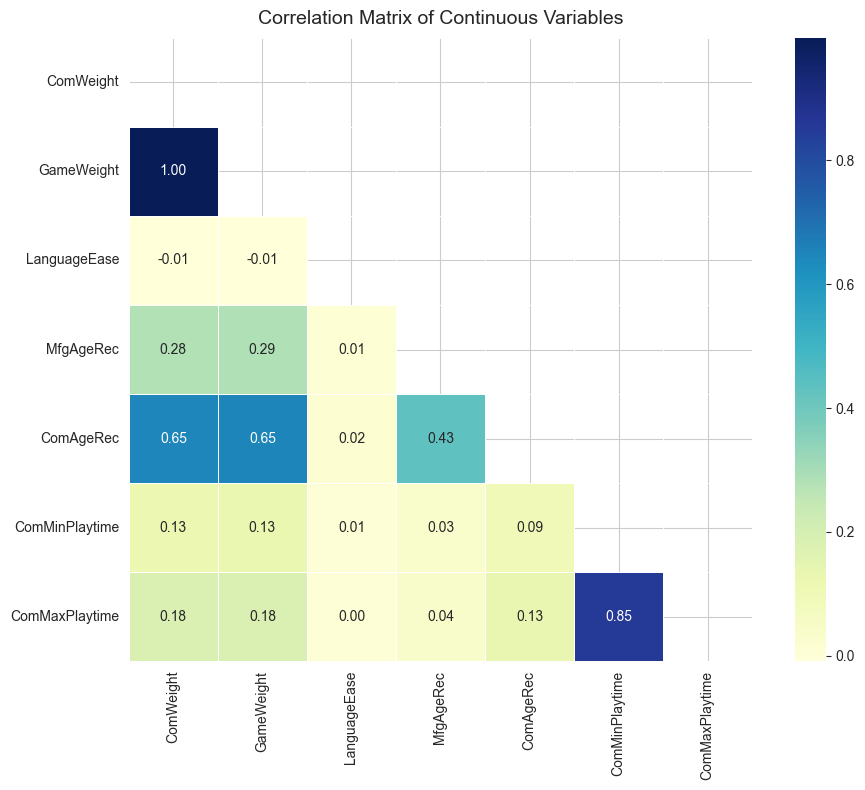

In [70]:
# matrix heatmap of correlation between continuous variables
numeric_df = df.select_dtypes(include=[np.number])
cols_to_insert = ['ComWeight', 'GameWeight', 'LanguageEase', 'MfgAgeRec',
                  'ComAgeRec','ComMinPlaytime', 'ComMaxPlaytime']
numeric_df = numeric_df[cols_to_insert]
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("Correlation Matrix of Continuous Variables", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [71]:
df

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating,Total_Categories
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,0,0,0,0,0,0,0,0,Low,0
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,0,0,0,0,0,0,0,0,Medium,0
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,0,0,0,0,0,0,0,0,High,0
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,0,0,0,0,0,0,0,0,Low,0
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,0,0,0,0,0,0,0,0,Medium,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21920,3233,Ballast,variation game quotpick sticksquot wooden cyli...,1998,1.0000,1.2096,2,4,8.0,11.0,...,0,0,0,0,0,0,0,0,Low,0
21921,13359,Leapfrog,leapfrog fun family game simple young gamer pl...,2004,1.5000,1.7219,1,6,6.0,361.0,...,0,0,0,0,0,0,0,0,Medium,0
21922,3295,Athos,monk climb athos mountain reach monastery move...,1993,1.6667,1.7946,2,4,11.0,431.0,...,0,0,0,0,0,0,0,0,Low,0
21923,176524,Hoplomachus: Origins,hoplomachu origin take story begin small battl...,2015,3.0370,3.2921,1,2,13.8,322.0,...,0,1,0,0,0,0,0,0,High,1


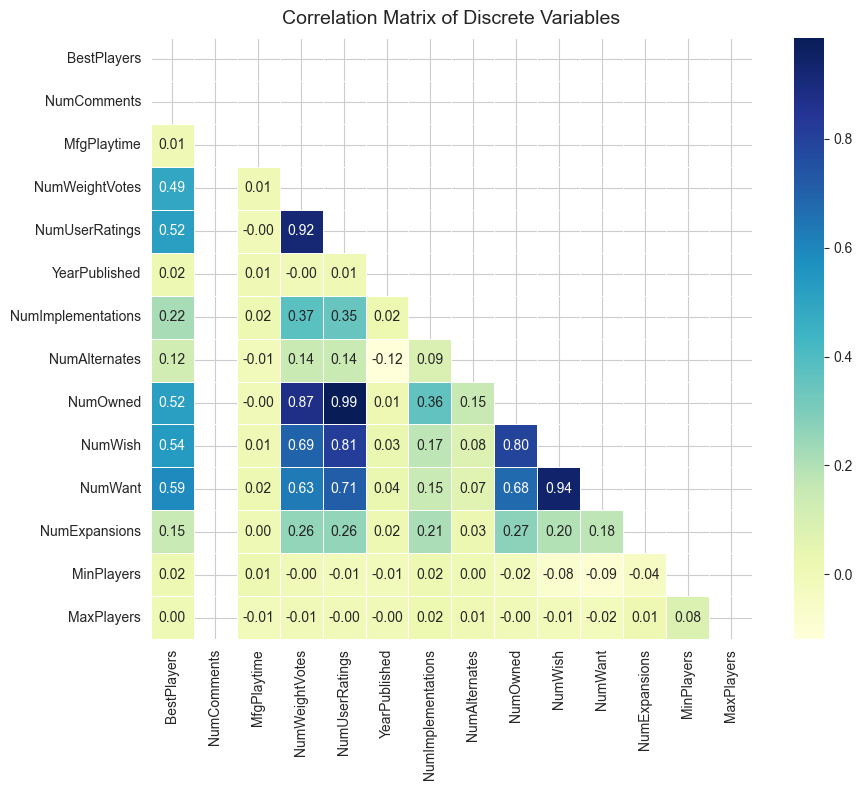

In [72]:
# matrix heatmap of correlation between discrete variables
numeric_df = df.select_dtypes(include=[np.number])
cols_to_insert = ['BestPlayers', 'NumComments', 'MfgPlaytime',
                  'NumWeightVotes','NumUserRatings', 'YearPublished','NumImplementations',
                  'NumAlternates','NumOwned', 'NumWish', 'NumWant','NumExpansions','MinPlayers',
                  'MaxPlayers']

numeric_df = numeric_df[cols_to_insert]
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("Correlation Matrix of Discrete Variables", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

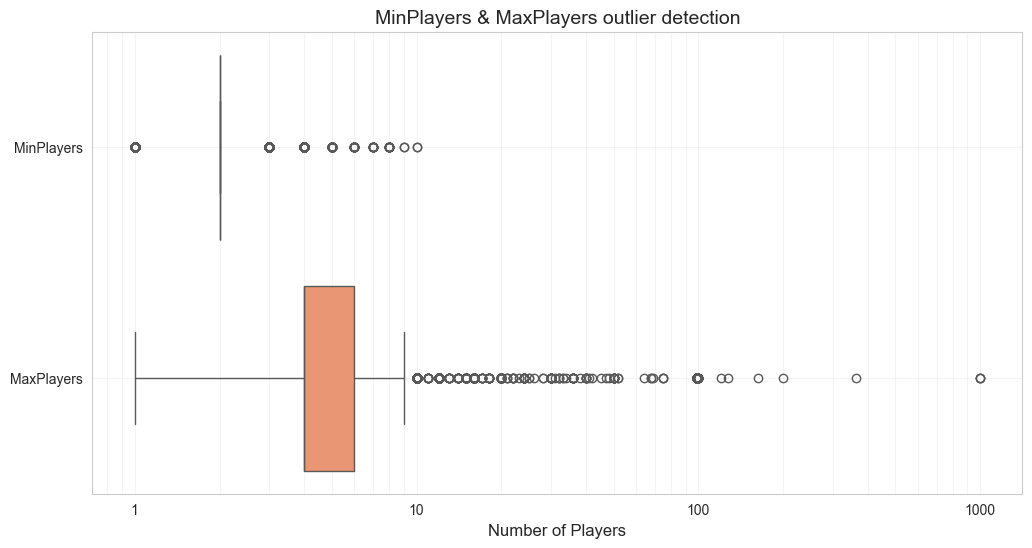

In [73]:
plt.figure(figsize=(12, 6))

# 1. Crea il Boxplot orizzontale
sns.boxplot(data=df[['MinPlayers', 'MaxPlayers']], orient='h', palette='Set2')

# 2. APPLICA LA SCALA LOGARITMICA ALL'ASSE X
plt.xscale('log')

# 3. Formattazione per rendere i numeri leggibili (es. 10, 100 invece di 10^1, 10^2)
plt.gca().xaxis.set_major_formatter(ScalarFormatter())

plt.title('MinPlayers & MaxPlayers outlier detection', fontsize=14)
plt.xlabel('Number of Players', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2) # Aggiunge una griglia leggera

plt.show()